# Week 5: Transfer Learning and Pretrained Models
In this lab, we will:
- Modify the final classification layer of a pre-trained ResNet for a new class count.
- Freeze and unfreeze parameters using `requires_grad` in PyTorch.
- Train only the new head.
- Compare transfer learning vs training from scratch in practical terms.

**Sumbission is required for this lab, it worths 2 points, please run all cells before submit.**

## Section 1: Overview

In this lab, we will use a pretrained CNN model ResNet. We will perform the following four stages:

### Stage 1: Load pre-trained backbone
```
model = models.resnet18(weights="DEFAULT")
```
This loads a pre-trained model called ResNet-18 with weights pre-trained on ImageNet.

### Stage 2: Replace the classifier
The pre-trained ResNet outputs 1,000 class logits. Your new task (e.g., 2 classes: healthy/damaged) needs a different output size.
```
model.fc = nn.Linear(512, num_classes=2)  # Replace final layer
```

### Stage 3: Freeze early layers, train the head
The pre-trained layers already know how to extract useful features. We only train the new final layer on our small dataset.

```

In [1]:
# Standard library imports for timing and reproducibility
import copy
import random
import time

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim

# Torchvision utilities for datasets and pretrained models
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# Set seeds for reproducible experiments in class
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[HAMI-core Msg(1571:140240574733632:libvgpu.c:839)]: Initializing.....


Using device: cuda


[HAMI-core Msg(1571:140240574733632:libvgpu.c:855)]: Initialized


## Section 2: Dataset Setup

We will use a real-world dataset `Flowers102`.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764707922935491..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.0000000076293944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027450992584228506..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764707922935491..1.0000000236034394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921580076217679..1.0000000236034394].
Clipping inp

Number of training samples: 1020
Number of validation samples: 1020
Number of classes: 102


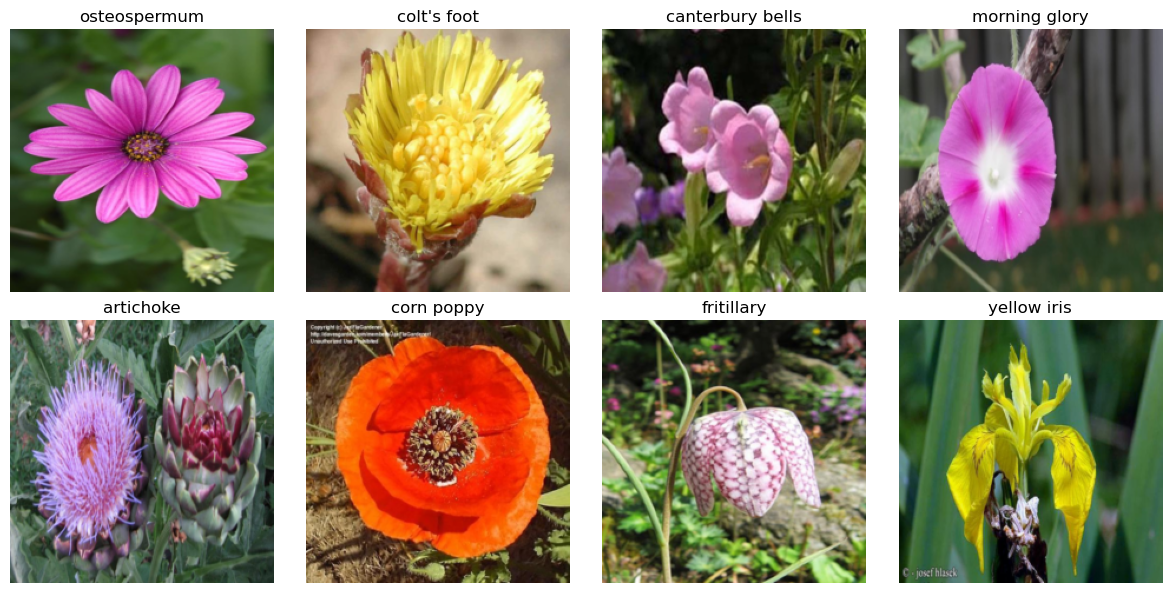

In [2]:
# Define preprocessing: resize for ResNet and normalize with ImageNet stats
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Try Oxford Flowers102 dataset for a more challenging test of transfer learning
train_data = datasets.Flowers102(root="./data", split="train", download=True, transform=transform)
val_data = datasets.Flowers102(root="./data", split="val", download=True, transform=transform)

# show statistics about the dataset
print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {len(train_data.classes)}")

# visualize some samples from the dataset
class_names = train_data.classes
plt.figure(figsize=(12, 6))
for i in range(8):  # show 8 random samples
    idx = random.randint(0, len(train_data)-1)
    img, label = train_data[idx]
    plt.subplot(2, 4, i+1)
    plt.imshow(img.permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    plt.title(class_names[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:

#preprocess the dataset to keep only two classes for faster training and easier debugging. You can increase these limits for better performance.
selected_classes = {0, 1}
max_train_samples = 800 # Use compact subsets to speed up training and debugging. You can increase these limits for better performance.
max_val_samples = 200 # Use compact subsets to speed up training and debugging. You can increase these limits for better performance.
train_idx = [i for i, (_, y) in enumerate(train_data) if y in selected_classes][:max_train_samples]
val_idx = [i for i, (_, y) in enumerate(val_data) if y in selected_classes][:max_val_samples]

train_data = Subset(train_data, train_idx)
val_data = Subset(val_data, val_idx)
class_names = ["Class_0", "Class_1"]

print("Using Flowers102 subset (2 classes).")


# TODO: Build dataloaders for mini-batch training
train_loader = DataLoader(train_data, batch_size=34, shuffle=True)
val_loader = DataLoader(val_data, batch_size=34, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Using Flowers102 subset (2 classes).
Train batches: 1, Val batches: 1


## Section 3: The Pre-trained Backbone

We will load a ResNet already trained on ImageNet.
Even though ImageNet has 1000 classes, early layers learn reusable visual patterns.

- Early filters often detect edges and textures.
- Middle layers detect parts and motifs.
- Final layer is task-specific and often replaced.

This is why we usually replace only the last layer first.

In [4]:
# TODO: Load pretrained ResNet-18 from torchvision using models.resnet18() and print the architecture summary to inspect the final layer. Identify the input size of the current classifier head (the final fully connected layer) and print it out.
# Load pretrained ResNet-18 from torchvision
# The weights contain useful visual knowledge from ImageNet

model = models.resnet18(weights="DEFAULT")

# Print architecture summary to inspect the final layer
print(model)

# Identify the input size of the current classifier head
in_features = model.fc.in_features
print(f"\nCurrent final layer input features: {in_features}")
print(f"Current final layer object: {model.fc}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Section 3: Fine-Tuning

### Step 3.1: Swap Head in PyTorch

You are adapting ResNet to a new domain with **2 classes**:

You need to replace the current `fc` layer with a new `nn.Linear` that outputs `num_classes`.
Do not modify backbone layers yet and only replace the head.

In [5]:
# TODO: Replace the final layer (the classifier head) of the pretrained ResNet-18 with a new fully connected layer that has an output size equal to the number of classes in your new dataset. This is a critical step in transfer learning, as it allows the model to make predictions for the new task while retaining the learned features from the pretrained backbone.
num_classes = 2 # Set the target class count for the new problem

model.fc = nn.Linear(512, 2) # Replace model.fc with a linear layer that has in_features equal to the original input features and out_features equal to num_classes

print(f"New final layer object: {model.fc}")


New final layer object: Linear(in_features=512, out_features=2, bias=True)


### Step 3.2: Strategic Freezing

Now tell PyTorch which parameters should learn.
When `requires_grad = False`, gradients are not stored for that parameter.
So backpropagation does **not** update that weight.

This is helpful when:
- your dataset is small,
- you want faster training,
- you want to preserve generic visual features.

In [6]:
# TODO: freeze the backbone of the model (all layers except the final classifier head) to prevent their weights from being updated during training. 
# This allows us to leverage the pretrained features while only training the new classifier head on our specific task. After freezing, set up an optimizer that only updates the parameters of the new head.
# Move model to target device before training setup
model = model.to(device)

# 1) Freeze all parameters in the model: iterating over model.parameters() and setting requires_grad to False
 
for param in model.parameters():       
    param.requires_grad = False

# 2) Re-enable gradients only for model.fc parameters: iterating over model.fc.parameters() and setting requires_grad to True
for param in model.fc.parameters():      
    param.requires_grad = True

# 3) Build an optimizer using ONLY trainable parameters, use Adam with a learning rate of 1e-3, and filter the model parameters to include only those where requires_grad is True
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# Quick sanity check: count trainable tensors
trainable_count = sum(p.requires_grad for p in model.parameters())
print(f"Trainable parameter tensors after freezing: {trainable_count}")

Trainable parameter tensors after freezing: 2


### Step 3.3: Training Loop

We choose cross-entropy as the loss function.

#### 
Inside each epoch, do two passes:
1. Training pass: set `model.train()`, loop over `train_loader`, then run zero_grad -> forward -> loss -> backward -> step.
2. Validation pass: set `model.eval()`, use `with torch.no_grad():`, loop over `val_loader`, and compute loss/accuracy only.

#### Common mistakes to avoid
- Do not mix training and validation batches in the same loop.
- Do not call `loss.backward()` or `optimizer.step()` during validation.
- Reset the running totals at the start of every epoch.

In [7]:
# Use cross-entropy for multi-class classification
criterion = nn.CrossEntropyLoss()

In [8]:
# Fine-tuning: train only the classifier head

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

torch.manual_seed(SEED)
num_epochs = 7

for epoch in range(num_epochs):
    # TODO: fill in the training loop to train the model for one epoch, tracking loss and accuracy for both training and validation sets. Use model.train() for training and model.eval() for evaluation. Remember to zero the gradients, perform backpropagation, and update the weights using the optimizer. After each epoch, evaluate the model on the validation set and store the loss and accuracy in the history dictionary.
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_running_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_running_loss / len(train_loader)
    train_acc = 100 * train_running_correct / train_total

    ## TODO: fill in the evaluation loop to evaluate the model on the validation set after each epoch, tracking loss and accuracy. Use model.eval() for evaluation and ensure that gradients are not computed during this phase to save memory and computation. After evaluating, store the loss and accuracy in the history dictionary.
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_running_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_running_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
    )

Epoch 1/7: Train Loss=0.6872, Train Acc=55.0000, Val Loss=0.7038, Val Acc=45.0000
Epoch 2/7: Train Loss=0.5747, Train Acc=75.0000, Val Loss=0.6712, Val Acc=60.0000
Epoch 3/7: Train Loss=0.5065, Train Acc=80.0000, Val Loss=0.6180, Val Acc=65.0000
Epoch 4/7: Train Loss=0.4410, Train Acc=80.0000, Val Loss=0.5551, Val Acc=75.0000
Epoch 5/7: Train Loss=0.3763, Train Acc=95.0000, Val Loss=0.4924, Val Acc=85.0000
Epoch 6/7: Train Loss=0.3188, Train Acc=100.0000, Val Loss=0.4355, Val Acc=85.0000
Epoch 7/7: Train Loss=0.2720, Train Acc=100.0000, Val Loss=0.3880, Val Acc=95.0000


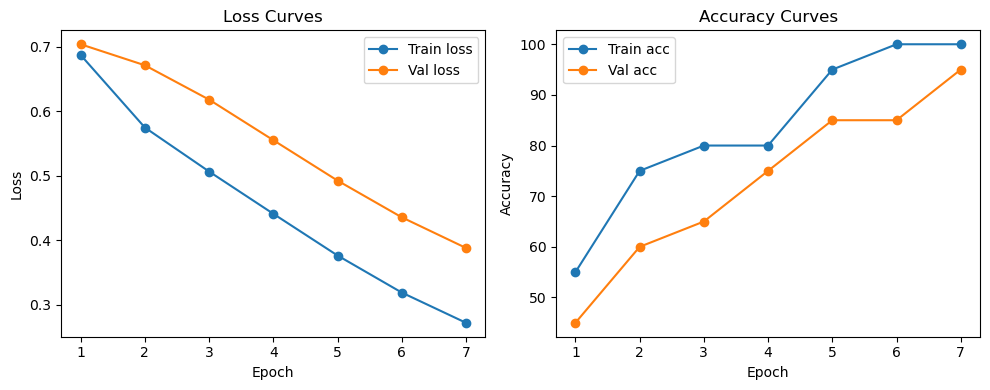

In [9]:
# Plot helper: training vs validation metrics
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))

# Left plot: loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

# Right plot: accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train acc")
plt.plot(epochs, history["val_acc"], marker="o", label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

### Reflections (need to provide answeres in the submission):

1. When we preprocessed the data, we normalized the inputs using ImageNet statistics, what is the benefit of this when using a model pre-trained on ImageNet?

Answer for Q1: It significantly reduces training time and saves computational resources, because the model has already learned general visual features. It also helps to prevent overfitting on small datasets and boosts the accuracy of our predicted labels by ensuring the input data matches what the pretrained model expects. The pretrained model learned patterns from ImageNet, and normalising our data to the same mean and standard deviation ensures that those patterns remain recognisable.

2. In your own words, explain why reusing the backbone is usually more data-efficient than training all layers from random initialization.

Answer for Q2: Grayscale X-rays differ significantly from colourful natural photos, so the pretrained features may not transfer well. I would unfreeze the middle or higher layers to allow the model to adapt to the new textures and patterns in X-ray images while keeping the early layers frozen, because they detect universal features like edges. If expanding the dataset is not feasible, adding extra convolutional layers can improve accuracy.

3. If you forget to swap the final layer, what mismatch error do you expect during training?

Answer for Q3: The model would have a shape mismatch error because it expects to output 1000 classes, but our dataset has only 2 classes. The loss function would fail because the output size does not match the target labels.

4. We set `requires_grad = False` for the backbone. When we call `loss.backward()`, do those frozen weights change?

Answer for Q4: No, they remain the same. When we set requires_grad = False, gradients are not computed or stored for those parameters. loss.backward() still runs but it skips the frozen layers, so the optimiser only updates the new head. This preserves the pretrained features while only training the new layer for our task.

5. If your source model learned from colorful natural photos but your target data are grayscale X-rays: would you freeze the whole backbone or unfreeze some middle/high layers, and why?
   
Answer for Q5: Grayscale images are different from coloured photos, so the pretrained features may not transfer perfectly. By unfreezing the middle or higher layers to allow the model to adapt to the new textures and patterns in X-ray images, while keeping the early layers frozen, because they detect universal features like edges. If expanding the dataset is not feasible, adding extra layers can improve feature extraction for better accuracy.


### Optional task:

Two-Stage Fine-Tuning:

- Stage 1 (5 epochs): Train only the new classifier head.

- Stage 2 (2 epochs): Unfreeze all layers and train with a **10x smaller learning rate**. 